# 01 · Linear and logistic regression: predictions, probabilities, and decisions

**Audience:** master's students in Computer Science. You should be comfortable with
Python, arrays, functions, and basic probability. The main lesson does not require
matrix calculus or a background in statistical inference.

By the end you should be able to:

1. Explain what a linear model learns and what its coefficients mean.
2. Read a loss function as a specification of which mistakes matter.
3. Compare a model with a baseline on unseen data, and recognize possible underfitting or overfitting.
4. Explain why regularization and training-only preprocessing are useful.
5. Distinguish a logistic score, a probability, and a final decision.
6. Explain precision, recall, and the consequences of changing a threshold.

**Main route (about 2 hours):** predict service latency → measure error → evaluate unseen
requests → inspect model limitations → use several features → predict a class probability
→ choose a decision threshold → evaluate the result.

**Optional extensions:** ranking curves, the mechanics of fitting, uncertainty bands,
and odds. These come after the exercises; skip them on a first pass.

## How to work through the notebook

For each example: **predict → run → interpret**. Read the question before executing the
cell, then explain the result in a sentence. Editing an experiment is useful only if you
can say what you changed and what outcome would support your explanation.

All figures and tables are saved here. To reproduce them, use **Restart Kernel and Run
All Cells**. Install `requirements.txt` first if needed; datasets run offline afterward.
The latency example is synthetic. Diabetes and Iris are public datasets bundled with
scikit-learn, with source links alongside the examples.

Our vocabulary: a **feature** is an input available when making a prediction; a
**target** is the outcome to predict; **parameters** are learned by fitting;
**hyperparameters** are choices such as regularization strength.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from scipy.special import expit
from sklearn.datasets import load_diabetes, load_iris
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, log_loss, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score)

SEED = 42
plt.rcParams.update({"figure.figsize": (8, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.2, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11})
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | scikit-learn {sklearn.__version__}")

Python 3.12.9 | NumPy 2.4.6 | scikit-learn 1.8.0


## 1. Start with the question, not the algorithm

Suppose we operate a service that processes uploaded files.

| Question | Output | Task |
|---|---|---|
| How long will this request take? | A number of milliseconds | Regression |
| Will it exceed our latency budget? | A probability, then a yes/no decision | Classification |

These questions are related, but they are not interchangeable. Knowing only the
predicted average time does not tell us the probability of exceeding a limit: we also
need information about how response times vary.

A learned model is a function whose parameters come from examples. We choose its
input features and family of functions, specify how errors are scored, and fit the
parameters. Then we check whether the function works on new examples.

**Discuss:** would the actual processing time be a valid input for predicting processing
time *before a request starts*? No: it would reveal the outcome after the decision was
supposed to be made. Available-at-prediction-time is part of the feature specification.

## 2. A line is a small, understandable prediction program

For one feature, a linear regression predicts
$$\text{predicted latency}=b+w\times\text{request size}.$$
Here $b$ is an intercept in milliseconds and $w$ is a slope in milliseconds per MB.
Think of them as two adjustable settings. Changing $b$ moves the line up or down;
changing $w$ changes how quickly predictions increase with file size.

We generate requests using `latency = 40 + 8 × size + noise`. The noise represents
unrecorded influences such as contention and timing variation. We know the hidden rule
because we wrote the simulation; for real data, that rule is not available.

Before fitting, set aside a **test set**. We will learn from the training requests and
use the test requests for a final check. Real service logs with time dependence would
usually need a chronological split; these simulated requests are independent.

**Predict:** will equal-size requests always take the same time?

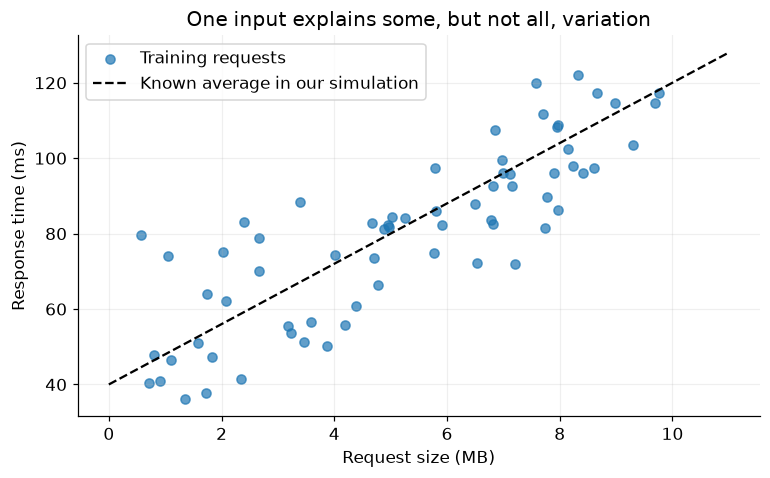

Training requests: 67; test requests reserved: 23


In [2]:
rng = np.random.default_rng(SEED)
request_mb = rng.uniform(0.5, 10, 90)
latency_ms = 40 + 8 * request_mb + rng.normal(0, 12, len(request_mb))
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    request_mb[:, None], latency_ms, test_size=0.25, random_state=SEED)
size_grid = np.linspace(0, 11, 160)[:, None]

fig, ax = plt.subplots()
ax.scatter(Xs_train[:, 0], ys_train, alpha=0.7, label="Training requests")
ax.plot(size_grid[:, 0], 40 + 8*size_grid[:, 0], "k--", label="Known average in our simulation")
ax.set(xlabel="Request size (MB)", ylabel="Response time (ms)", title="One input explains some, but not all, variation")
ax.legend()
plt.show()
print(f"Training requests: {len(ys_train)}; test requests reserved: {len(ys_test)}")

**Read the plot:** points fluctuate around the hidden average. A useful line describes
a trend; it does not need to pass through every point. The scatter is not automatically
a bug or evidence that training has failed.

An intercept can describe a fixed overhead in this simulation. In a real model, $b$
is simply the predicted value at zero input; that interpretation may be unreliable
if zero is outside the observed range. Likewise, extending the line to 1,000 MB would
be an extrapolation, not an evaluated capability.

## 3. How do we decide which line is better?

For a request, the **residual** is `observed time − predicted time`.
A residual of +12 ms means the model predicted 12 ms too little.
Ordinary least squares chooses the line with the smallest total squared residuals.
Equivalently, it minimizes the mean squared error:
$$\mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\widehat y_i)^2.$$
Here $n$ is the number of requests, $y_i$ is the observed time, and $\widehat y_i$ is
its prediction. Squaring prevents positive and negative errors from canceling and
makes large errors expensive. Errors of 2 and 10 contribute 4 and 100 respectively.

**Predict:** which of the three candidate lines below will have the smallest training
MSE? Is the steepest line necessarily best?

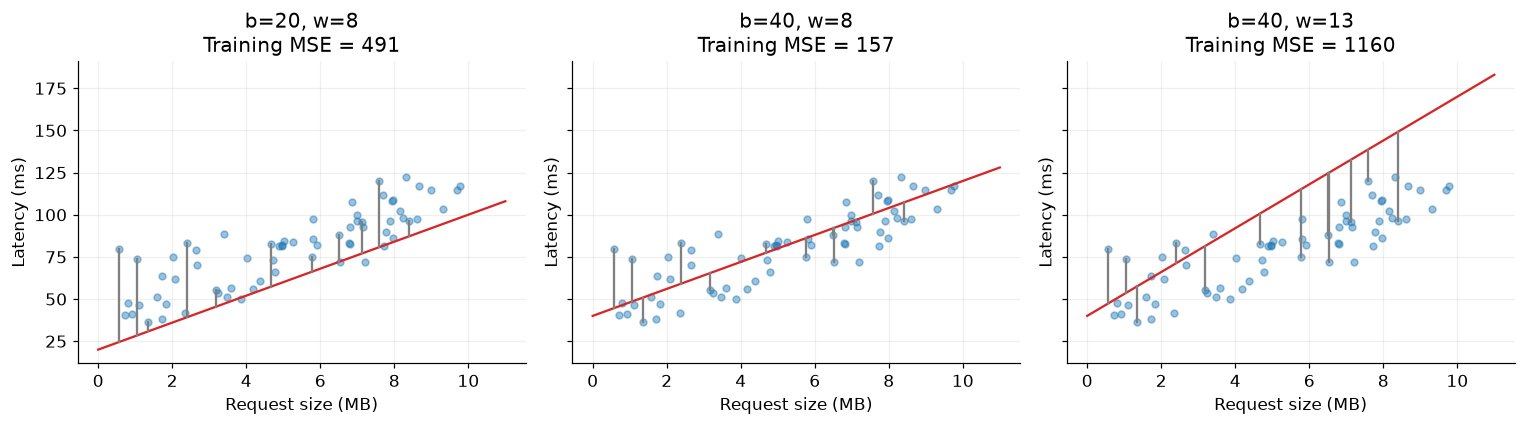

In [3]:
candidates = [(20, 8), (40, 8), (40, 13)]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, (intercept, slope) in zip(axes, candidates):
    predictions = intercept + slope * Xs_train[:, 0]
    mse = mean_squared_error(ys_train, predictions)
    ax.scatter(Xs_train[:, 0], ys_train, s=20, alpha=0.45)
    ax.plot(size_grid[:, 0], intercept + slope*size_grid[:, 0], color="tab:red")
    for j in range(0, len(ys_train), 6):
        ax.plot([Xs_train[j, 0]]*2, [ys_train[j], predictions[j]], color="gray")
    ax.set(title=f"b={intercept}, w={slope}\nTraining MSE = {mse:.0f}",
           xlabel="Request size (MB)", ylabel="Latency (ms)")
plt.tight_layout()
plt.show()

**Read the plot:** the gray segments measure errors in the quantity we are predicting,
so they are vertical, not perpendicular to the line. A line may look plausible and
still systematically predict too little. The loss makes our comparison explicit.

The hidden generating line need not be the exact best fit to this finite, noisy sample.
`LinearRegression.fit` searches for the best coefficients for the observed training
loss. It uses a numerical least-squares solver; you do not need to implement matrix
inversion to use or explain this model.

## 4. Fit the model, then ask whether it beats a simple baseline

Our baseline ignores request size and predicts the average **training** latency for
every request. If a fitted model cannot beat a useful simple baseline, extra complexity
needs justification.

We report **MAE**, the average absolute error, and **RMSE**, the square root of MSE.
Both have units of milliseconds. MAE is the direct average error magnitude; RMSE gives
large errors more influence. Neither says that every request lies within that distance.

**Predict:** can training error be small while error on new requests is large?

Learned rule: latency ≈ 42.8 + 7.2 × size (ms)
Prediction for a 5 MB request: 78.5 ms


,Test MAE (ms),Test RMSE (ms)
Model,,
Predict the training mean,14.69,19.29
Use request size,7.39,8.46


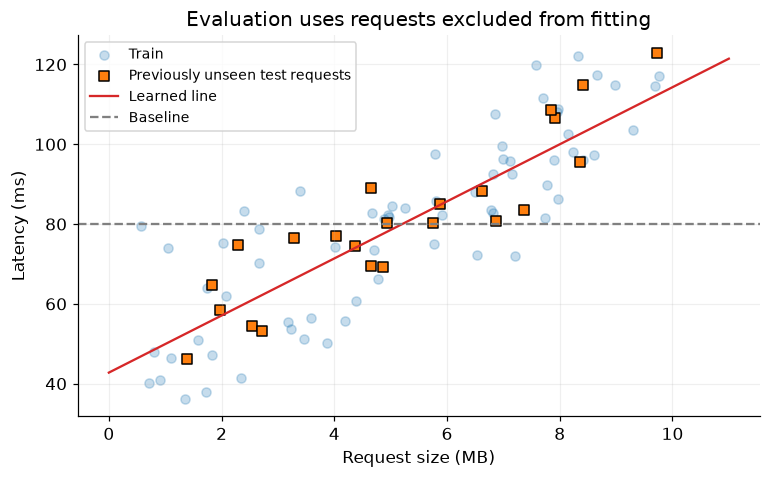

In [4]:
service_model = LinearRegression().fit(Xs_train, ys_train)
service_baseline = DummyRegressor(strategy="mean").fit(Xs_train, ys_train)
print(f"Learned rule: latency ≈ {service_model.intercept_:.1f} + "
      f"{service_model.coef_[0]:.1f} × size (ms)")
print(f"Prediction for a 5 MB request: {service_model.predict([[5]])[0]:.1f} ms")

rows = []
for name, model in [("Predict the training mean", service_baseline), ("Use request size", service_model)]:
    prediction = model.predict(Xs_test)
    rows.append({"Model": name, "Test MAE (ms)": mean_absolute_error(ys_test, prediction),
                 "Test RMSE (ms)": np.sqrt(mean_squared_error(ys_test, prediction))})
display(pd.DataFrame(rows).set_index("Model").round(2))
fig, ax = plt.subplots()
ax.scatter(Xs_train[:, 0], ys_train, alpha=0.25, label="Train")
ax.scatter(Xs_test[:, 0], ys_test, marker="s", edgecolor="black", label="Previously unseen test requests")
ax.plot(size_grid[:, 0], service_model.predict(size_grid), color="tab:red", label="Learned line")
ax.axhline(ys_train.mean(), color="gray", ls="--", label="Baseline")
ax.set(xlabel="Request size (MB)", ylabel="Latency (ms)", title="Evaluation uses requests excluded from fitting")
ax.legend(fontsize=9)
plt.show()

**Interpret:** state the test MAE with its unit. Then explain whether using request size
helped relative to the baseline. A good training score alone would not answer that question.

Training is like developing against example inputs. A test set is an evaluation on
held-out inputs, but there is one important difference from ordinary software tests:
repeatedly changing a learned model to improve the same test score leaks information
about that set. Use a validation set or cross-validation for model choices, and keep
test data for the final check.

**Underfitting:** the model cannot represent an important pattern. **Overfitting:** it
learns details of the training sample that do not transfer to new data. Neither is
identified by model size alone; look at both training and validation behavior.

## 5. A good fit still needs inspection

A single score can hide a systematic mistake. Consider a second, deliberately curved
latency simulation: larger requests incur increasing overhead. We fit a line to it
only to inspect what the line misses; this is not another held-out performance claim.

A **residual plot** places prediction errors against input or fitted values.
A curve in this plot suggests that a straight-line assumption is missing structure.

**Predict:** if the true trend bends upward, will residuals look like unstructured noise?

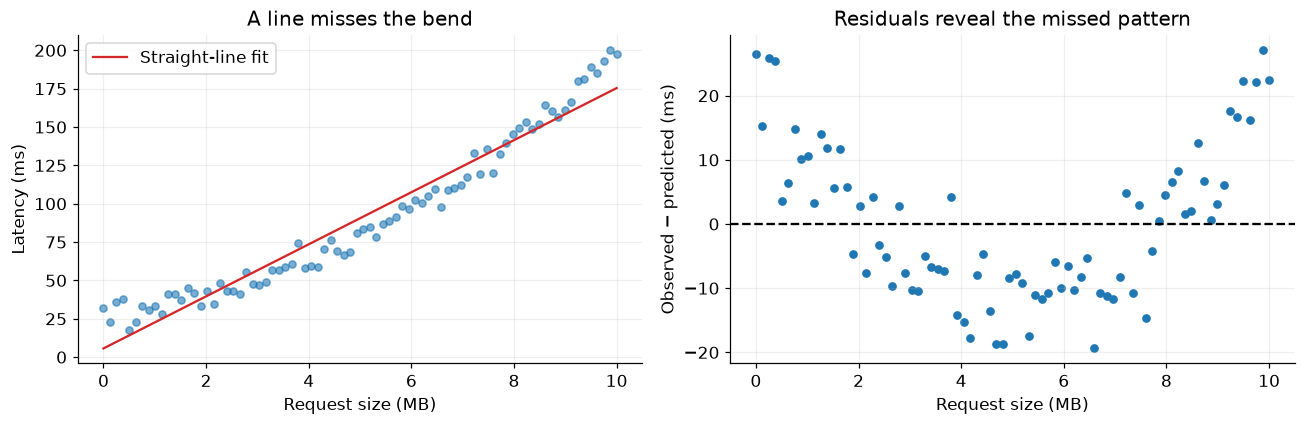

In [5]:
curve_rng = np.random.default_rng(SEED)
curve_size = np.linspace(0, 10, 80)
curve_latency = 30 + 2*curve_size + 1.5*curve_size**2 + curve_rng.normal(0, 7, 80)
wrong_shape = LinearRegression().fit(curve_size[:, None], curve_latency)
curve_prediction = wrong_shape.predict(curve_size[:, None])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(curve_size, curve_latency, s=22, alpha=0.6)
axes[0].plot(curve_size, curve_prediction, color="tab:red", label="Straight-line fit")
axes[0].set(xlabel="Request size (MB)", ylabel="Latency (ms)", title="A line misses the bend")
axes[0].legend()
axes[1].scatter(curve_size, curve_latency-curve_prediction, s=22)
axes[1].axhline(0, color="black", ls="--")
axes[1].set(xlabel="Request size (MB)", ylabel="Observed − predicted (ms)", title="Residuals reveal the missed pattern")
plt.tight_layout()
plt.show()

**Read the plot:** the U-shaped residual pattern says that errors depend on request size.
Training longer will not let a straight line express this bend. We could introduce a
`squared_size` feature or use another model family, then evaluate that choice with
training-only validation.

More features are not automatically better. A highly flexible model can also follow
random fluctuations. And even a correct mean trend leaves unpredictable variation:
**uncertainty about the average** differs from **variation in the next request**.
Optional extension C visualizes that distinction.

## 6. Several features, regularization, and a realistic workflow

With several features, linear regression is a weighted sum:
$$\widehat y=b+w_1x_1+w_2x_2+\cdots+w_px_p.$$
Each coefficient describes how the prediction changes when its feature changes and
the other included features stay fixed. That is a statement about this model, not
proof that changing the feature would cause the outcome to change.

Our public-data example uses ten baseline measurements to predict a numerical disease
progression measure. Its small size makes it useful for learning, not for drawing
medical conclusions. [Dataset description](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset);
[online OLS/ridge example](https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols_ridge.html).

Some inputs overlap in the information they provide. A model can assign large,
compensating weights to them. **Ridge regularization** discourages large coefficients:
$$\text{training objective}=\text{sum of squared errors}+\alpha\sum_j w_j^2.$$
The intercept is not penalized. Small $\alpha$ permits a closer training fit; large
$\alpha$ puts more pressure on coefficients to stay small. Too much can underfit.
We standardize features because coefficient magnitude depends on measurement units.

In [6]:
diabetes = load_diabetes(as_frame=True, scaled=False)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.25, random_state=SEED)
print("Training rows / test rows:", len(yd_train), len(yd_test))
display(Xd_train.head(3))

# A pipeline learns preprocessing from the same training rows as the model.
ridge_pipeline = make_pipeline(StandardScaler(), Ridge())
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_search = GridSearchCV(ridge_pipeline, {"ridge__alpha": alphas},
    cv=KFold(5, shuffle=True, random_state=SEED), scoring="neg_mean_squared_error")
ridge_search.fit(Xd_train, yd_train)
print("Regularization strength selected using training data:", ridge_search.best_params_["ridge__alpha"])

Training rows / test rows: 331 111


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
16,47.0,1.0,30.3,109.0,207.0,100.2,70.0,3.00,5.2149,98.0
408,66.0,1.0,21.7,126.0,212.0,127.8,45.0,4.71,5.2781,101.0
432,51.0,1.0,31.5,93.0,231.0,144.0,49.0,4.70,5.2523,117.0


Regularization strength selected using training data: 1


### What did that search actually do?

For each proposed `alpha`, five-fold cross-validation repeatedly fits on four training
folds and scores on the fifth. It averages those validation results and selects a
setting. Then it refits that setting on all training rows. The test rows are excluded
from every one of those decisions.

`Pipeline` also refits the scaler inside each fold. Fitting a scaler to the full dataset
first would allow validation/test information into preprocessing. `neg_mean_squared_error`
is negative only because scikit-learn's search API treats larger scores as better.

**Predict:** will the strongest penalty always give the best validation result?

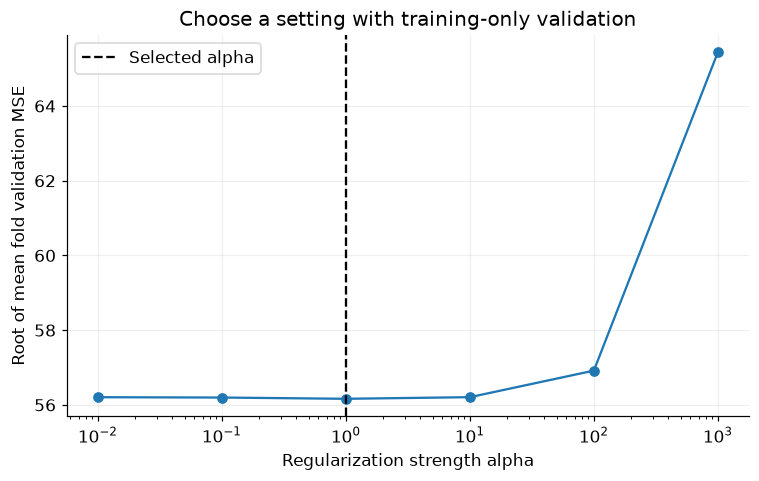

,Test RMSE,Test MAE,Test R²
Model,,,
Training-mean baseline,74.881,65.527,-0.014
All-feature linear regression,53.370,41.549,0.485
CV-selected ridge,53.318,41.507,0.486


In [7]:
validation_rmse = np.sqrt(-ridge_search.cv_results_["mean_test_score"])
fig, ax = plt.subplots()
ax.semilogx(alphas, validation_rmse, "o-")
ax.axvline(ridge_search.best_params_["ridge__alpha"], color="black", ls="--", label="Selected alpha")
ax.set(xlabel="Regularization strength alpha", ylabel="Root of mean fold validation MSE",
       title="Choose a setting with training-only validation")
ax.legend()
plt.show()

# These comparisons are specified before inspecting test results.
diabetes_models = {
    "Training-mean baseline": DummyRegressor().fit(Xd_train, yd_train),
    "All-feature linear regression": LinearRegression().fit(Xd_train, yd_train),
    "CV-selected ridge": ridge_search.best_estimator_,
}
rows = []
for name, model in diabetes_models.items():
    pred = model.predict(Xd_test)
    rows.append({"Model": name, "Test RMSE": np.sqrt(mean_squared_error(yd_test, pred)),
                 "Test MAE": mean_absolute_error(yd_test, pred), "Test R²": r2_score(yd_test, pred)})
display(pd.DataFrame(rows).set_index("Model").round(3))

**Interpret:** compare both learned models with the baseline before comparing them
with each other. If ridge and unregularized regression are nearly tied, report that;
do not turn a tiny difference on one test split into a universal ranking.

$R^2$ compares squared prediction error with always predicting the mean of the evaluated
targets: 1 is perfect, 0 matches that mean, and a negative value is worse. Our baseline
uses the *training* mean, so its test $R^2$ can be slightly negative. $R^2$ is not
“percentage of predictions that are correct.”

**Checkpoint:** explain why `alpha` is a hyperparameter, while the fitted weights are
parameters. Then explain why preprocessing belongs inside the pipeline.

## 7. Classification starts with a score and a probability

Now the desired outcome is a class. Logistic regression still computes a weighted sum,
but uses it as a **score**, then converts it to a probability:
$$z=b+w_1x_1+\cdots+w_px_p,\qquad p=\frac{1}{1+e^{-z}}.$$
The conversion is called the **sigmoid**. A score of 0 gives probability 0.5, a score
of about 2 gives 0.88, and about −2 gives 0.12. It keeps the output between 0 and 1.

There are three different objects:

1. **Score:** unrestricted numerical evidence for class 1.
2. **Probability:** the model's estimated chance of class 1.
3. **Decision:** classify as 1 when that probability crosses a chosen threshold.

A positive weight increases the score when its feature increases, holding others fixed.
Its change to probability depends on where we are on the sigmoid; it is not a fixed
percentage-point increase.

**Predict:** does raising the score from 0 to 1 change probability as much as raising
it from 5 to 6?

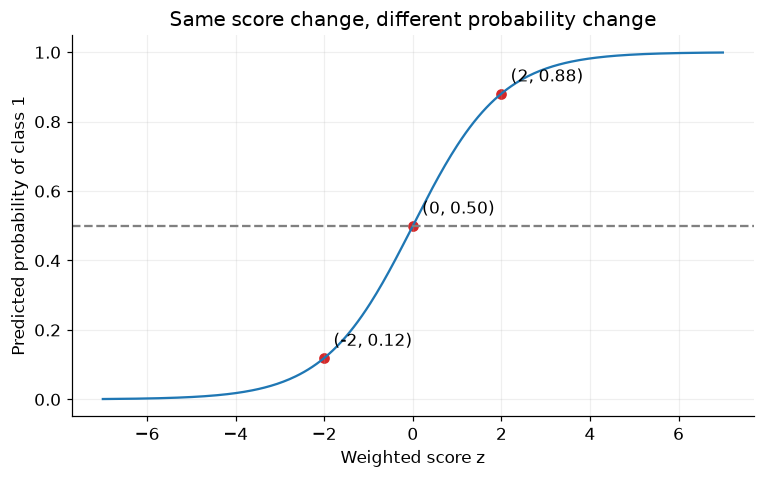

In [8]:
scores = np.linspace(-7, 7, 300)
fig, ax = plt.subplots()
ax.plot(scores, expit(scores), label="Sigmoid")
for score in [-2, 0, 2]:
    ax.scatter(score, expit(score), color="tab:red")
    ax.annotate(f"({score}, {expit(score):.2f})", (score, expit(score)), xytext=(6, 8), textcoords="offset points")
ax.axhline(0.5, color="gray", ls="--")
ax.set(xlabel="Weighted score z", ylabel="Predicted probability of class 1", title="Same score change, different probability change")
plt.show()

## 8. What does a good probability prediction mean?

For a positive example (`y=1`), a model assigning probability 0.9 to class 1 should be
rewarded more than one assigning 0.6. A model assigning 0.001 should be penalized
strongly. **Log loss** measures this by taking the negative logarithm of the probability
assigned to the outcome that actually happened:
$$\text{loss}=\begin{cases}-\log(p),&y=1,\\-\log(1-p),&y=0.\end{cases}$$
Training averages this loss over examples, with a regularization penalty in the usual
scikit-learn implementation. The familiar binary cross-entropy formula in neural
network training is the same loss written compactly.

**Predict:** two models both predict class 0 for a positive case, one with `p=0.49`
and one with `p=0.001`. Are the two errors equally bad under log loss?

,P(class 1),Decision at 0.5,Log loss if true class is 1
0,0.001,0,6.908
1,0.100,0,2.303
2,0.490,0,0.713
3,0.600,1,0.511
4,0.900,1,0.105
5,0.990,1,0.010


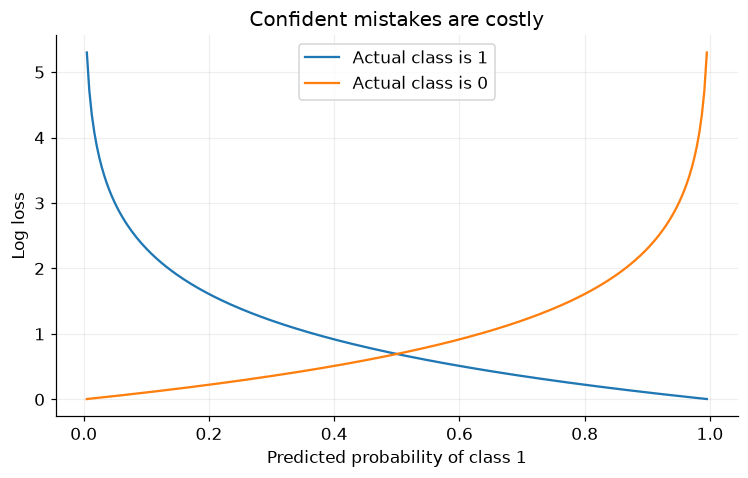

In [9]:
example_probabilities = np.array([0.001, 0.1, 0.49, 0.6, 0.9, 0.99])
display(pd.DataFrame({"P(class 1)": example_probabilities,
    "Decision at 0.5": (example_probabilities >= 0.5).astype(int),
    "Log loss if true class is 1": -np.log(example_probabilities)}).round(3))
p = np.linspace(0.005, 0.995, 250)
fig, ax = plt.subplots()
ax.plot(p, -np.log(p), label="Actual class is 1")
ax.plot(p, -np.log1p(-p), label="Actual class is 0")
ax.set(xlabel="Predicted probability of class 1", ylabel="Log loss", title="Confident mistakes are costly")
ax.legend()
plt.show()

**Interpret:** accuracy discards confidence after converting probabilities to labels.
Log loss retains it. A model can have the same accuracy as another but much worse log loss.

A probability of 0.8 does not guarantee that one particular case is positive. For a
well-calibrated model, roughly 80% of many comparable cases assigned 0.8 would be
positive. Producing numbers in [0, 1] does not by itself establish calibration.

## 9. A visible classification example: two Iris species

Predict **versicolor (0)** versus **virginica (1)** from petal length and width.
Two input features let us draw every model prediction on a flat plot. Species overlap,
so this is more informative than an example with perfectly separated classes.
[UCI Iris provenance](https://archive.ics.uci.edu/dataset/53/iris).

We keep 30% of the flowers for testing and use a scaled logistic model with a fixed,
predeclared `C=1`. Smaller `C` means stronger regularization, the reverse direction
from ridge's `alpha`. We already demonstrated tuning with ridge; this example keeps
the model setting fixed so we can focus on probabilities and decisions.

**Predict:** will a straight decision boundary require a straight probability surface?

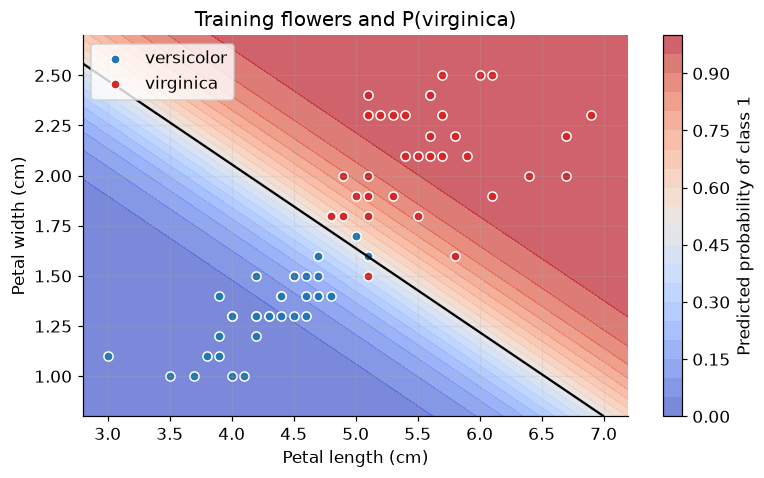

In [10]:
iris = load_iris()
keep = iris.target != 0
X_flower = iris.data[keep, 2:4]
y_flower = (iris.target[keep] == 2).astype(int)
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_flower, y_flower, test_size=0.3, stratify=y_flower, random_state=SEED)
logit = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=2000))
logit.fit(Xf_train, yf_train)

xx, yy = np.meshgrid(np.linspace(2.8, 7.2, 160), np.linspace(0.8, 2.7, 140))
mesh = np.c_[xx.ravel(), yy.ravel()]
surface = logit.predict_proba(mesh)[:, 1].reshape(xx.shape)
fig, ax = plt.subplots()
contour = ax.contourf(xx, yy, surface, levels=np.linspace(0, 1, 21), cmap="coolwarm", alpha=0.7)
ax.contour(xx, yy, surface, levels=[0.5], colors="black")
for label, name in [(0, "versicolor"), (1, "virginica")]:
    mask = yf_train == label
    ax.scatter(Xf_train[mask, 0], Xf_train[mask, 1], label=name,
               color=["tab:blue", "tab:red"][label], edgecolor="white")
ax.set(xlabel="Petal length (cm)", ylabel="Petal width (cm)", title="Training flowers and P(virginica)")
fig.colorbar(contour, ax=ax, label="Predicted probability of class 1")
ax.legend()
plt.show()

**Read the plot:** the background is a probability; the points are observed species.
The black line is the 0.5 decision boundary. At that boundary the weighted score is
zero, so it is a straight line in these two features. The sigmoid changes probabilities
smoothly on either side. Adding nonlinear features could produce a curved boundary
in the original measurements.

Do not read certainty into empty corners of the plot. A model returns a probability
there even when little relevant data supports it.

## 10. A probability is not yet a decision

Imagine a spam filter: a false positive hides a legitimate message, while a false
negative lets spam through. Different applications can prefer different tradeoffs.
For Iris, we use “virginica” as the positive class simply to make the mechanics visible.

- **Precision:** among flowers predicted as virginica, how many really are virginica?
- **Recall:** among actual virginica flowers, how many did we find?

Lowering the threshold labels more cases positive. Recall cannot decrease for a fixed
set of probabilities; false positives cannot decrease either. Precision may rise or
fall, depending on which examples cross the threshold.

We compare thresholds on **out-of-fold predictions from training data**: each flower's
probability comes from a model fitted without that flower's fold. This is a validation
demonstration; the test labels are still untouched. `cross_val_predict` runs the repeated
fits for us, including the scaler.

**Predict:** will changing only the threshold require retraining the model?

,False positives,False negatives,Precision,Recall
Threshold,,,,
0.3,3,0,0.921,1.000
0.5,2,1,0.944,0.971
0.7,0,5,1.000,0.857


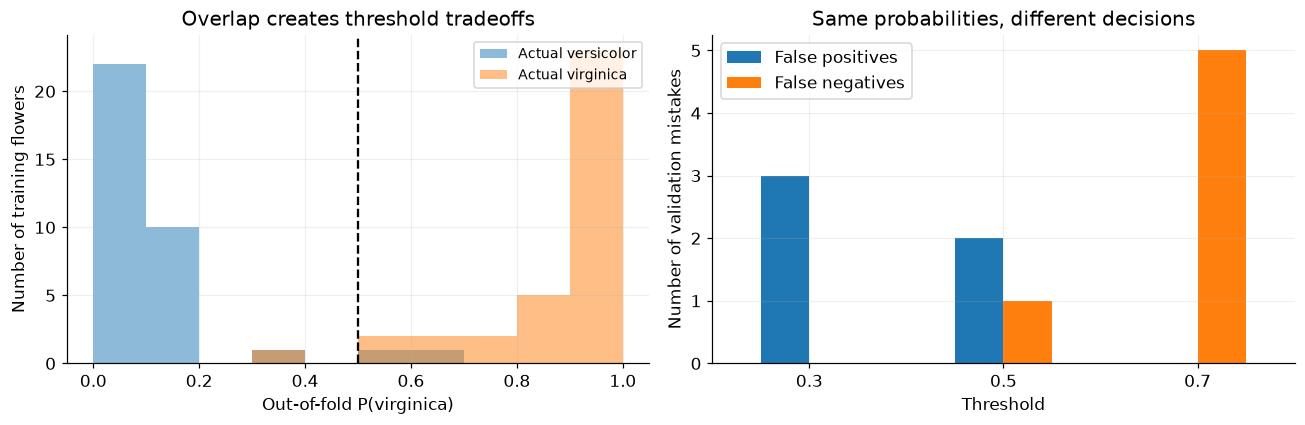

In [11]:
validation_probability = cross_val_predict(logit, Xf_train, yf_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method="predict_proba")[:, 1]
thresholds = [0.3, 0.5, 0.7]
threshold_rows = []
for threshold in thresholds:
    labels = (validation_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(yf_train, labels).ravel()
    threshold_rows.append({"Threshold": threshold, "False positives": fp, "False negatives": fn,
        "Precision": precision_score(yf_train, labels, zero_division=0),
        "Recall": recall_score(yf_train, labels, zero_division=0)})
threshold_table = pd.DataFrame(threshold_rows).set_index("Threshold")
display(threshold_table.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, name in [(0, "Actual versicolor"), (1, "Actual virginica")]:
    axes[0].hist(validation_probability[yf_train == label], bins=np.linspace(0, 1, 11), alpha=0.5, label=name)
axes[0].axvline(0.5, color="black", ls="--")
axes[0].set(xlabel="Out-of-fold P(virginica)", ylabel="Number of training flowers", title="Overlap creates threshold tradeoffs")
axes[0].legend(fontsize=9)
threshold_table[["False positives", "False negatives"]].plot.bar(ax=axes[1], rot=0)
axes[1].set(ylabel="Number of validation mistakes", title="Same probabilities, different decisions")
plt.tight_layout()
plt.show()

**Interpret:** changing a threshold is a decision-policy change, not a refit of the
probability model. Choose a policy using application costs and validation data.
For the final demonstration below, we keep the predeclared threshold of 0.5.

If a false negative costs four times as much as a false positive and probabilities
are calibrated, a cost-based threshold would be 0.2. The instructor notes explain
this by comparing the two expected costs. Iris has no natural four-to-one error cost;
this is a separate decision-making illustration, not a claim about flowers.

## 11. Evaluate the chosen model and decision rule on the test set

We now make predictions on the reserved test flowers. A confusion matrix separates
the two kinds of mistake. Accuracy gives an overall fraction, precision and recall
show positive-class behavior, and log loss checks the probability predictions.

**Predict:** can a model with high accuracy still be useless when positive examples
are very rare? Consider predicting “not spam” for every message when 99% are legitimate.

Accuracy                 0.900
Precision (virginica)    0.929
Recall (virginica)       0.867
Log loss                 0.217
dtype: float64

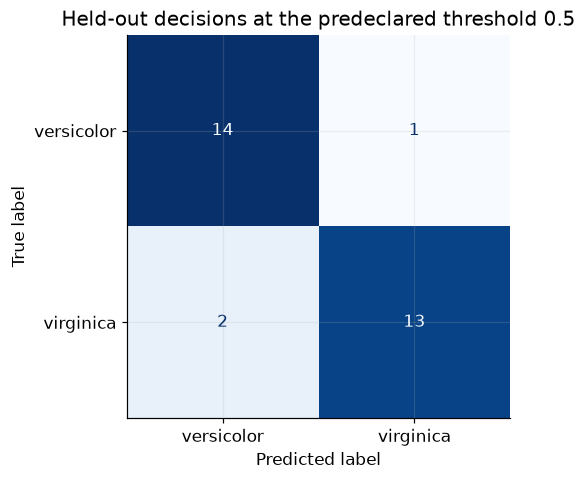

In [12]:
test_probability = logit.predict_proba(Xf_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)
display(pd.Series({"Accuracy": accuracy_score(yf_test, test_prediction),
    "Precision (virginica)": precision_score(yf_test, test_prediction),
    "Recall (virginica)": recall_score(yf_test, test_prediction),
    "Log loss": log_loss(yf_test, test_probability)}).round(3))
fig, ax = plt.subplots(figsize=(6, 4.5))
ConfusionMatrixDisplay.from_predictions(yf_test, test_prediction,
    display_labels=["versicolor", "virginica"], cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Held-out decisions at the predeclared threshold 0.5")
plt.tight_layout()
plt.show()

**Interpret:** read one false positive and one false negative in words. Count how many
of the 30 test flowers are correct. Each changed prediction moves accuracy by about
3.3 percentage points, so avoid overinterpreting small differences.

Accuracy can be misleading with rare positive classes; the all-negative spam filter
has 99% accuracy and zero recall for spam. The Iris split is balanced, so that specific
imbalance problem does not explain its results. Metric choice should follow the task.

## 12. Connect the two models

| Question | Linear regression | Logistic regression |
|---|---|---|
| What is predicted? | A numerical outcome | A class probability |
| What is learned? | Intercept and feature weights | Intercept and feature weights |
| What happens to the weighted sum? | It is the numerical prediction | Sigmoid converts it to a probability |
| What loss measures fit? | Squared error | Log loss / binary cross-entropy |
| Where does the decision policy enter? | Through downstream use of the prediction | Through a threshold applied afterward |
| What must be checked? | Error size, residual patterns, generalization | Probability quality, error types, generalization |

For either model: define the prediction-time inputs, split the data, build a baseline,
fit preprocessing within training data, choose settings using validation, and evaluate
on test data after choices are fixed. Explain errors in terms of the application.

**Four ideas to retain:** a weighted sum is an understandable starting model; loss
defines which mistakes matter; performance must transfer to unseen examples; a useful
probability and a useful decision are related but different goals.

## 13. Exercises: explain first, then experiment

1. The model is `latency = 35 + 9 × size`. Explain both coefficients and predict a 4 MB
   request. Why might predicting a 1,000 MB request be unreliable?
2. Two residuals are +10 and −10 ms. Compute their mean residual, MAE, and MSE. Why is
   mean residual alone a poor performance measure?
3. A model has training MAE 2 ms and validation MAE 25 ms. Another has 8 ms and 10 ms.
   Which is the more promising starting point for deployment, and what would you check next?
4. Fit a linear model with a squared-size feature to the curved simulation in section 5.
   First make a fresh train/validation split for that experiment. Compare residual shapes
   and validation error; do not claim success from training error alone.
5. A teammate standardizes the full dataset before splitting. Explain the problem and
   show how a pipeline fixes it. Why does this matter even though scaling does not use labels?
6. A spam model returns 0.65. What are its decisions at thresholds 0.5 and 0.8? Has its
   probability estimate changed? Describe which type of error each threshold emphasizes.
7. Two models both classify a positive case as negative, with probabilities 0.49 and
   0.001. Compare accuracy and log loss for this case. Which is the more confident mistake?
8. Sketch a 2×2 confusion matrix with 8 true positives, 2 false negatives, 3 false positives,
   and 87 true negatives. Calculate accuracy, precision, and recall. Give one reason accuracy
   alone does not fully describe its usefulness.

### Answer notes

1. 35 ms is the zero-size prediction; each extra MB adds 9 ms to the model prediction.
   At 4 MB: 71 ms. A 1,000 MB request is far outside the demonstrated input range.
2. Mean residual 0 ms, MAE 10 ms, MSE 100 ms². Signed errors cancel.
3. The second generalizes better on the validation data. Check representative data,
   baseline performance, error costs, and the final held-out evaluation. These scores
   alone do not establish production readiness.
4. Use `PolynomialFeatures(degree=2, include_bias=False)` with `LinearRegression` in a
   pipeline, or construct the deterministic square explicitly. The bend should become
   easier to represent; the important evidence is validation behavior.
5. Full-data means and scales use information from held-out observations. A pipeline
   learns these quantities only on each training split, then applies them to held-out rows.
6. Positive at 0.5, negative at 0.8; probability stays 0.65. A higher threshold makes
   false positives less likely and false negatives more likely for fixed predictions.
7. Both are errors at threshold 0.5; log losses are about 0.713 and 6.908. The second
   assigns almost no probability to the event that occurred.
8. Accuracy 95%, precision $8/11\approx72.7\%$, recall $8/10=80\%$. The majority of
   negatives helps accuracy look high while two positives are still missed.

## Optional A. Ranking: ROC and precision–recall curves

The main lesson used one decision threshold. A ranking curve asks how performance
changes across thresholds. ROC plots recall against false-positive rate; its AUC
summarizes ranking (with the usual tie convention). Precision–recall directly shows
which precision/recall combinations can be obtained as the threshold moves.

Average precision summarizes precision using recall increments. The PR reference
precision is the positive-class prevalence. Good ranking does not establish calibrated
probabilities, and a high AUC does not choose a decision policy for an application.
We show these curves for the already fixed model; we do not use the test curves to tune it.

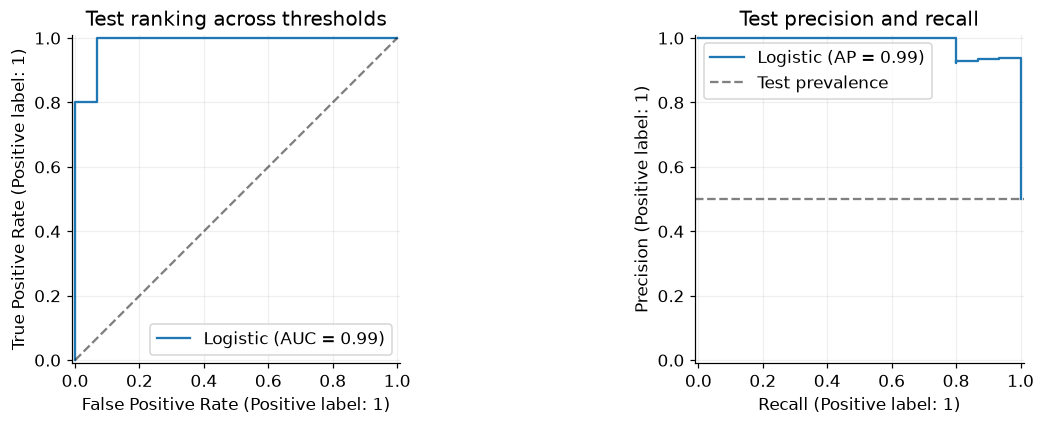

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(yf_test, test_probability, ax=axes[0], name="Logistic")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("Test ranking across thresholds")
PrecisionRecallDisplay.from_predictions(yf_test, test_probability, ax=axes[1], name="Logistic")
axes[1].axhline(yf_test.mean(), color="gray", ls="--", label="Test prevalence")
axes[1].set_title("Test precision and recall")
axes[1].legend()
plt.tight_layout()
plt.show()

## Optional B. What happens inside `fit`?

For readers who want the mathematical connection, add a column of ones to the feature
matrix to represent the intercept; call the result $A$. Let $\beta$ collect the intercept
and weights. Least squares solves
$$\min_\beta\|y-A\beta\|^2,\qquad A^T(A\widehat\beta-y)=0.$$
When columns are independent this yields the familiar inverse formula. In code use a
least-squares solver rather than forming an inverse. Correlated or duplicate columns
can make coefficients unstable or nonunique even when fitted predictions are useful.

Gradient descent takes repeated small steps in a direction that reduces the loss.
For half-MSE, the gradient is $A^T(A\beta-y)/n$: a combination of prediction errors
weighted by the corresponding inputs. The example below uses standardized inputs
and a conservative step size. Its convergence is a check for this example, not a
universal guarantee for that step size.

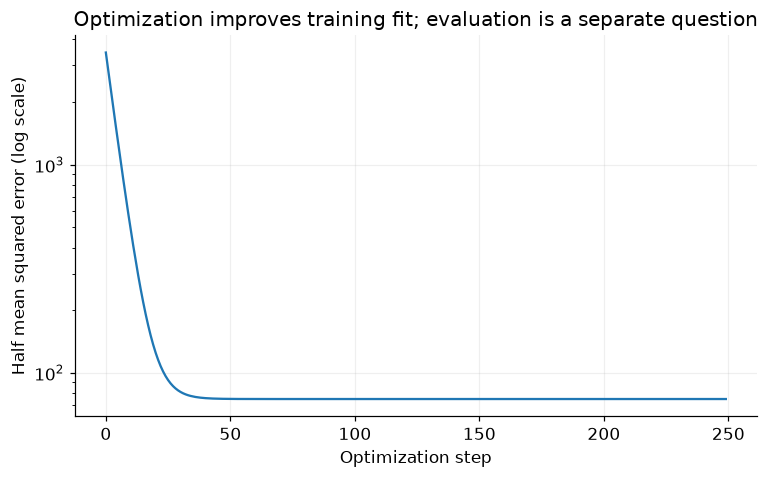

In [14]:
scaled_size = StandardScaler().fit_transform(Xs_train)
A = np.column_stack([np.ones(len(scaled_size)), scaled_size[:, 0]])
beta_exact = np.linalg.lstsq(A, ys_train, rcond=None)[0]
beta_iterative = np.zeros(2)
losses = []
for step in range(250):
    error = A @ beta_iterative - ys_train
    losses.append(np.mean(error**2) / 2)
    beta_iterative -= 0.1 * (A.T @ error) / len(ys_train)
assert np.allclose(A @ beta_exact, service_model.predict(Xs_train))
assert np.allclose(beta_iterative, beta_exact, atol=1e-7)
assert np.allclose(A.T @ (ys_train-A @ beta_exact), 0, atol=1e-8)
fig, ax = plt.subplots()
ax.semilogy(losses)
ax.set(xlabel="Optimization step", ylabel="Half mean squared error (log scale)", title="Optimization improves training fit; evaluation is a separate question")
plt.show()

Logistic regression uses the same design matrix but a different prediction and loss:
$$p_i=\sigma(a_i^T\beta),\qquad
J=-\frac1n\sum_i[y_i\log p_i+(1-y_i)\log(1-p_i)].$$
The expression simply selects `−log(p)` for a positive case and `−log(1−p)` for a
negative case. It is also the negative log likelihood of independent Bernoulli labels.
Its gradient is $A^T(p-y)/n$, again a weighted combination of prediction errors, this
time in probability space. Regularization adds its own term to the training objective.
There is no OLS-style closed-form logistic solution; numerical optimization is used.

Squared error also has a likelihood interpretation under Gaussian errors, but normality
is not required just to compute a least-squares fit. Distributional assumptions become
more important when making the precise interval statements in the next extension.

## Optional C. Uncertainty about an average versus a new request

An estimated average can be precise while individual requests still vary substantially.
A **confidence interval for the mean** describes uncertainty in the estimated average;
a **prediction interval** also allows for the new request's noise, so it is wider.

The next code computes classical pointwise 95% intervals for the synthetic linear
service example. They assume a correct linear mean, independent Gaussian errors with
constant variance, and a full-rank design. The simulation meets those assumptions.
They do not protect against an incorrect model or a change in the operating environment.
Reading the two bands is the learning objective; deriving them is optional.

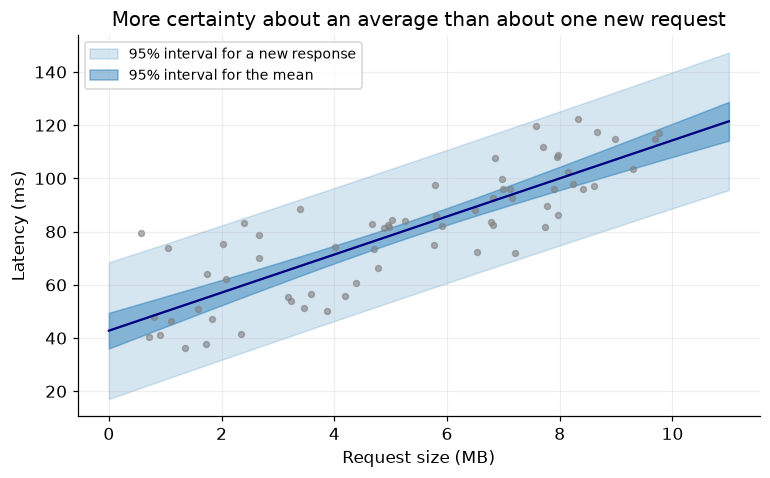

In [15]:
from scipy.stats import t

# Simple one-feature interval formulas; fit only on training requests.
x_train = Xs_train[:, 0]
residual = ys_train-service_model.predict(Xs_train)
noise_variance = np.sum(residual**2) / (len(ys_train)-2)
x_grid = size_grid[:, 0]
leverage = 1/len(x_train) + (x_grid-x_train.mean())**2 / np.sum((x_train-x_train.mean())**2)
critical = t.ppf(0.975, df=len(ys_train)-2)
mean_halfwidth = critical * np.sqrt(noise_variance * leverage)
new_request_halfwidth = critical * np.sqrt(noise_variance * (1+leverage))
mean_prediction = service_model.predict(size_grid)
fig, ax = plt.subplots()
ax.fill_between(x_grid, mean_prediction-new_request_halfwidth, mean_prediction+new_request_halfwidth,
                alpha=0.18, color="tab:blue", label="95% interval for a new response")
ax.fill_between(x_grid, mean_prediction-mean_halfwidth, mean_prediction+mean_halfwidth,
                alpha=0.45, color="tab:blue", label="95% interval for the mean")
ax.plot(x_grid, mean_prediction, color="navy")
ax.scatter(Xs_train[:, 0], ys_train, s=15, color="gray", alpha=0.6)
ax.set(xlabel="Request size (MB)", ylabel="Latency (ms)", title="More certainty about an average than about one new request")
ax.legend(fontsize=9)
plt.show()

**Interpret:** the narrow band is not intended to contain 95% of the individual response
times. In repeated datasets under the assumptions, each interval procedure covers its
stated target at the nominal rate. The bands are pointwise, not a joint guarantee over
the entire curve. More data can reduce uncertainty in the average without removing the
irreducible noise of a new request.

## Optional D. Odds and coefficients

For probability $p$, odds are $p/(1-p)$: probability 0.8 means odds 4 to 1. Logistic
regression makes **log odds** a weighted sum. Increasing feature $j$ by one unit multiplies
odds by $e^{w_j}$, holding other inputs fixed; it does not add a fixed amount to probability.
If features were standardized, that unit is one training standard deviation.

For more than two classes, multinomial logistic regression produces one probability
per class using a softmax. The same ideas remain: fitted scores, a probability loss,
regularization, and an application-specific decision rule.

## References

- [scikit-learn linear-model guide](https://scikit-learn.org/stable/modules/linear_model.html)
- [OLS and ridge visual example](https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols_ridge.html)
- [Bundled datasets and provenance](https://scikit-learn.org/stable/datasets/toy_dataset.html)
- [UCI Iris](https://archive.ics.uci.edu/dataset/53/iris)

The service simulations, explanations, and plots were written for this lesson. Public
datasets and online example ideas are acknowledged above. Next course: trees express
predictions with local rules rather than one global weighted sum.